In [1]:
import numpy as np
from IPython.display import clear_output
import time
import random
# https://www.youtube.com/watch?v=UXW2yZndl7U

In [2]:
def update_board(board_temp,color,column):
    # this is a function that takes the current board status, a color, and a column and outputs the new board status
    # columns 0 - 6 are for putting a checker on the board: if column is full just return the current board...this should be forbidden by the player

    # the color input should be either 'plus' or 'minus'

    board = board_temp.copy()
    ncol = board.shape[1]
    nrow = board.shape[0]

    # this seems silly, but actually faster to run than using sum because of overhead!
    colsum = abs(board[0,column])+abs(board[1,column])+abs(board[2,column])+abs(board[3,column])+abs(board[4,column])+abs(board[5,column])
    row = int(5-colsum)
    if row > -0.5:
        if color == 'plus':
            board[row,column] = 1
        else:
            board[row,column] = -1
    return board

# in this code the board is a 6x7 numpy array.  Each entry is +1, -1 or 0.  You WILL be able to do a better
# job training your neural network if you rearrange this to be a 6x7x2 numpy array.  If the i'th row and j'th
# column is +1, this can be represented by board[i,j,0]=1.  If it is -1, this can be represented by
# board[i,j,1]=1. It's up to you how you represent your board.


In [3]:
def board_to_2D(board):
    out = np.empty(board.shape + (2,), dtype=np.int8)
    np.equal(board,  1, out=out[..., 0])
    np.equal(board, -1, out=out[..., 1])
    return out

In [4]:
board = np.zeros((6,7))
board = update_board(board,'plus',3)
board = update_board(board,'minus',3)
board = update_board(board,'plus',3)
board = update_board(board,'minus',3)
board = update_board(board,'plus',3)
board = update_board(board,'minus',3)
print(board)
board = update_board(board,'plus',3)
print(board)

[[ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]]
[[ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]]


In [5]:
# print(board_to_2D(board))
print(board_to_2D(board).shape)

(6, 7, 2)


In [6]:
def check_for_win_slow(board):
    # this function checks to see if anyone has won on the given board
    nrow = board.shape[0]
    ncol = board.shape[1]
    winner = 'nobody'
    for col in range(ncol):
        for row in reversed(range(nrow)):
            if abs(board[row,col]) < 0.1: # if this cell is empty, all the cells above it are too!
                break
            # check for vertical winners
            if row <= (nrow-4): # can't have a column go from rows 4-7...
                tempsum = board[row,col]+board[row+1,col]+board[row+2,col]+board[row+3,col] # this is WAY faster than np.sum!!!
                if tempsum==4:
                    winner = 'v-plus'
                    return winner
                elif tempsum==-4:
                    winner = 'v-minus'
                    return winner
            # check for horizontal winners
            if col <= (ncol-4):
                tempsum = board[row,col]+board[row,col+1]+board[row,col+2]+board[row,col+3]
                if tempsum==4:
                    winner = 'h-plus'
                    return winner
                elif tempsum==-4:
                    winner = 'h-minus'
                    return winner
            # check for top left to bottom right diagonal winners
            if (row <= (nrow-4)) and (col <= (ncol-4)):
                tempsum = board[row,col]+board[row+1,col+1]+board[row+2,col+2]+board[row+3,col+3]
                if tempsum==4:
                    winner = 'd-plus'
                    return winner
                elif tempsum==-4:
                    winner = 'd-minus'
                    return winner
            # check for top right to bottom left diagonal winners
            if (row <= (nrow-4)) and (col >= 3):
                tempsum = board[row,col]+board[row+1,col-1]+board[row+2,col-2]+board[row+3,col-3]
                if tempsum==4:
                    winner = 'd-plus'
                    return winner
                elif tempsum==-4:
                    winner = 'd-minus'
                    return winner
    return winner

In [7]:
def check_for_win(board,col):
    # this code is faster than the above code, but it requires knowing where the last checker was dropped
    # it may seem extreme, but in MCTS this function is called more than anything and actually makes up
    # a large portion of total time spent finding a good move.  So every microsecond is worth saving!
    nrow = 6
    ncol = 7
    # take advantage of knowing what column was last played in...need to check way fewer possibilities
    colsum = abs(board[0,col])+abs(board[1,col])+abs(board[2,col])+abs(board[3,col])+abs(board[4,col])+abs(board[5,col])
    row = int(6-colsum)
    if row+3<6:
        vert = board[row,col] + board[row+1,col] + board[row+2,col] + board[row+3,col]
        if vert == 4:
            return 'v-plus'
        elif vert == -4:
            return 'v-minus'
    if col+3<7:
        hor = board[row,col] + board[row,col+1] + board[row,col+2] + board[row,col+3]
        if hor == 4:
            return 'h-plus'
        elif hor == -4:
            return 'h-minus'
    if col-1>=0 and col+2<7:
        hor = board[row,col-1] + board[row,col] + board[row,col+1] + board[row,col+2]
        if hor == 4:
            return 'h-plus'
        elif hor == -4:
            return 'h-minus'
    if col-2>=0 and col+1<7:
        hor = board[row,col-2] + board[row,col-1] + board[row,col] + board[row,col+1]
        if hor == 4:
            return 'h-plus'
        elif hor == -4:
            return 'h-minus'
    if col-3>=0:
        hor = board[row,col-3] + board[row,col-2] + board[row,col-1] + board[row,col]
        if hor == 4:
            return 'h-plus'
        elif hor == -4:
            return 'h-minus'
    if row < 3 and col < 4:
        DR = board[row,col] + board[row+1,col+1] + board[row+2,col+2] + board[row+3,col+3]
        if DR == 4:
            return 'd-plus'
        elif DR == -4:
            return 'd-minus'
    if row-1>=0 and col-1>=0 and row+2<6 and col+2<7:
        DR = board[row-1,col-1] + board[row,col] + board[row+1,col+1] + board[row+2,col+2]
        if DR == 4:
            return 'd-plus'
        elif DR == -4:
            return 'd-minus'
    if row-2>=0 and col-2>=0 and row+1<6 and col+1<7:
        DR = board[row-2,col-2] + board[row-1,col-1] + board[row,col] + board[row+1,col+1]
        if DR == 4:
            return 'd-plus'
        elif DR == -4:
            return 'd-minus'
    if row-3>=0 and col-3>=0:
        DR = board[row-3,col-3] + board[row-2,col-2] + board[row-1,col-1] + board[row,col]
        if DR == 4:
            return 'd-plus'
        elif DR == -4:
            return 'd-minus'
    if row+3<6 and col-3>=0:
        DL = board[row,col] + board[row+1,col-1] + board[row+2,col-2] + board[row+3,col-3]
        if DL == 4:
            return 'd-plus'
        elif DL == -4:
            return 'd-minus'
    if row-1 >= 0 and col+1 < 7 and row+2<6 and col-2>=0:
        DL = board[row-1,col+1] + board[row,col] + board[row+1,col-1] + board[row+2,col-2]
        if DL == 4:
            return 'd-plus'
        elif DL == -4:
            return 'd-minus'
    if row-2 >=0 and col+2<7 and row+1<6 and col-1>=0:
        DL = board[row-2,col+2] + board[row-1,col+1] + board[row,col] + board[row+1,col-1]
        if DL == 4:
            return 'd-plus'
        elif DL == -4:
            return 'd-minus'
    if row-3>=0 and col+3<7:
        DL = board[row-3,col+3] + board[row-2,col+2] + board[row-1,col+1] + board[row,col]
        if DL == 4:
            return 'd-plus'
        elif DL == -4:
            return 'd-minus'
    return 'nobody'

In [8]:
def find_legal(board):
    legal = [i for i in range(7) if abs(board[0,i]) < 0.1]
    return legal

In [9]:
def look_for_win(board_,color):
    board_ = board_.copy()
    legal = find_legal(board_)
    winner = -1
    for m in legal:
        bt = update_board(board_.copy(),color,m)
        wi = check_for_win(bt,m)
        if wi[2:] == color:
            winner = m
            break
    return winner

In [10]:
def find_all_nonlosers(board,color):
    if color == 'plus':
        opp = 'minus'
    else:
        opp = 'plus'
    legal = find_legal(board)
    poss_boards = [update_board(board,color,l) for l in legal]
    poss_legal = [find_legal(b) for b in poss_boards]
    allowed = []
    for i in range(len(legal)):
        wins = [j for j in poss_legal[i] if check_for_win(update_board(poss_boards[i],opp,j),j) != 'nobody']
        if len(wins) == 0:
            allowed.append(legal[i])
    return allowed

In [11]:
def back_prop(winner,path,color0,md):
    for i in range(len(path)):
        board_temp = path[i]

        md[board_temp][0]+=1
        if winner[2]==color0[0]:
            if i % 2 == 1:
                md[board_temp][1] += 1
            else:
                md[board_temp][1] -= 1
        elif winner[2]=='e': # tie
            # md[board_temp][1] += 0
            pass
        else:
            if i % 2 == 1:
                md[board_temp][1] -= 1
            else:
                md[board_temp][1] += 1

In [12]:
def rollout(board,next_player):
    winner = 'nobody'
    player = next_player
    while winner == 'nobody':
        legal = find_legal(board)
        if len(legal) == 0:
            winner = 'tie'
            return winner
        move = random.choice(legal)
        board = update_board(board,player,move)
        winner = check_for_win(board,move)

        if player == 'plus':
            player = 'minus'
        else:
            player = 'plus'
    return winner


In [13]:
def mcts(board_temp,color0,nsteps):
    # nsteps is a parameter that determines the skill (and slowness) of the player
    # bigger values of nsteps means the player is better, but also slower to figure out a move.
    board = board_temp.copy()
    ##############################################
    winColumn = look_for_win(board,color0) # check to find a winning column
    if winColumn > -0.5:
        return winColumn # if there is one - play that!
    legal0 = find_all_nonlosers(board,color0) # find all moves that won't immediately lead to your opponent winning
    if len(legal0) == 0: # if you can't block your opponent - just find the 'best' losing move
        legal0 = find_legal(board)
    ##############################################
    # the code above, in between the hash rows, is not part of traditional MCTS
    # but it makes it better and faster - so I included it!
    # MCTS occasionally makes stupid mistakes
    # like not dropping the checker on a winning column, or not blocking an obvious opponent win
    # this avoids a little bit of that stupidity!
    # we could also add this logic to the rest of the MCTS and rollout functions - I just haven't done that yet...
    # feel free to experiment!
    mcts_dict = {tuple(board.ravel()):[0,0]}
    for ijk in range(nsteps):
        color = color0
        winner = 'nobody'
        board_mcts = board.copy()
        path = [tuple(board_mcts.ravel())]
        while winner == 'nobody':
            legal = find_legal(board_mcts)
            if len(legal) == 0:
                winner = 'tie'
                back_prop(winner,path,color0,mcts_dict)
                break
            board_list = []
            for col in legal:
                board_list.append(tuple(update_board(board_mcts,color,col).ravel()))
            for bl in board_list:
                if bl not in mcts_dict.keys():
                    mcts_dict[bl] = [0,0]
            ucb1 = np.zeros(len(legal))
            for i in range(len(legal)):
                num_denom = mcts_dict[board_list[i]]
                if num_denom[0] == 0:
                    ucb1[i] = 10*nsteps
                else:
                    ucb1[i] = num_denom[1]/num_denom[0] + 2*np.sqrt(np.log(mcts_dict[path[-1]][0])/mcts_dict[board_list[i]][0])
            chosen = np.argmax(ucb1)

            board_mcts = update_board(board_mcts,color,legal[chosen])
            path.append(tuple(board_mcts.ravel()))
            winner = check_for_win(board_mcts,legal[chosen])
            if winner[2]==color[0]:
                back_prop(winner,path,color0,mcts_dict)
                break
            if color == 'plus':
                color = 'minus'
            else:
                color = 'plus'
            if mcts_dict[tuple(board_mcts.ravel())][0] == 0:
                winner = rollout(board_mcts,color)
                back_prop(winner,path,color0,mcts_dict)
                break

    maxval = -np.inf
    best_col = -1
    for col in legal0:
        board_temp = tuple(update_board(board,color0,col).ravel())
        num_denom = mcts_dict[board_temp]
        if num_denom[0] == 0:
            compare = -np.inf
        else:
            compare = num_denom[1] / num_denom[0]
        if compare > maxval:
            maxval = compare
            best_col = col
    return (best_col)


In [14]:
# mcts(np.zeros((6,7)),'plus',5000)

In [15]:
# board = np.zeros((6,7))
# winner = 'nobody'
# color = 'plus'
# while winner == 'nobody':
#     if color == 'minus':
#         col = mcts(board,color,300)
#     else:
#         col = mcts(board,color,1500)
#     board = update_board(board,color,col)
#     winner = check_for_win(board,col)
#     if color == 'plus':
#         color = 'minus'
#     else:
#         color = 'plus'
#     print(board)
#     print('=========================')
# print(winner)

In [16]:
import numpy as np
import random
from collections import defaultdict, Counter

# =========================
# Helpers
# =========================
def flip_perspective_2D(board_2D):
    """
    Swap plus/minus planes so NN always sees 'plus to move'
    """
    return board_2D[..., ::-1]

def board_key(board):
    """
    Hashable board representation for deduplication
    """
    return tuple(board.ravel())


# =========================
# Dataset Generator
# =========================

def generate_dataset(
    n_games=5000,
    mcts_steps=800,
    random_opening_max=4,
    seed=0
):
    """
    Generates (X, y) using MCTS self-play

    Returns:
        X : (N,6,7,2) int8
        y : (N,) int64
    """
    rng = np.random.default_rng(seed)

    # store multiple labels per board for majority vote
    board_to_moves = defaultdict(list)

    for g in range(n_games):
        board = np.zeros((6,7), dtype=np.int8)
        color = 'plus'
        winner = 'nobody'

        # -------------------------
        # Random opening (NO LABELS)
        # -------------------------
        n_open = rng.integers(0, random_opening_max + 1)
        for _ in range(n_open):
            legal = find_legal(board)
            if not legal:
                break
            move = rng.choice(legal)
            board = update_board(board, color, move)
            winner = check_for_win(board, move)
            if winner != 'nobody':
                break
            color = 'minus' if color == 'plus' else 'plus'

        if winner != 'nobody':
            continue

        # -------------------------
        # MCTS self-play (LABELLED)
        # -------------------------
        while True:
            legal = find_legal(board)
            if not legal:
                break

            # MCTS expects board from current player's perspective
            if color == 'plus':
                mcts_board = board
                board_2D = board_to_2D(board)
            else:
                mcts_board = -board
                board_2D = flip_perspective_2D(board_to_2D(board))

            best_move = mcts(mcts_board, 'plus', mcts_steps)

            # store label
            board_to_moves[board_key(board_2D)].append(best_move)

            # play the move
            board = update_board(board, color, best_move)
            winner = check_for_win(board, best_move)
            if winner != 'nobody':
                break

            color = 'minus' if color == 'plus' else 'plus'

        if (g + 1) % 250 == 0:
            print(f"Games completed: {g+1}")

    # -------------------------
    # Majority vote cleanup
    # -------------------------
    X, y = [], []
    for key, moves in board_to_moves.items():
        best = Counter(moves).most_common(1)[0][0]
        board_2D = np.array(key, dtype=np.int8).reshape(6,7,2)
        X.append(board_2D)
        y.append(best)

    X = np.stack(X).astype(np.int8)
    y = np.array(y, dtype=np.int64)

    return X, y

In [17]:
# # =========================
# # Run + Save
# # =========================
# X, y = generate_dataset(
#     n_games=10000,
#     mcts_steps=1000,
#     random_opening_max=4,
#     seed=42
# )

# print("Dataset shape:", X.shape, y.shape)

# np.save("X_10000_1000_4.npy", X)
# np.save("y_10000_1000_4.npy", y)

# print("Saved: X_10000_1000_4.npy, y_10000_1000_4.npy")

In [18]:
# import numpy as np
# from collections import Counter

# # ---------- Fast encoding ----------
# def board_to_2D_fast(board):
#     # board: (6,7) int8 {-1,0,1} -> (6,7,2) uint8 {0,1}
#     out = np.empty((6,7,2), dtype=np.uint8)
#     np.equal(board,  1, out=out[..., 0])
#     np.equal(board, -1, out=out[..., 1])
#     return out

# def flip_perspective_2D_inplace(board_2D):
#     # swap channels (no allocation)
#     board_2D[..., [0,1]] = board_2D[..., [1,0]]
#     return board_2D

# def majority_vote_labels(keys_bytes, labels):
#     """
#     keys_bytes: (N,) array of dtype 'S84' (since 6*7*2=84 bytes in uint8)
#     labels:     (N,) int64
#     Returns unique_keys_bytes, majority_labels
#     """
#     # group by key
#     uniq, inv = np.unique(keys_bytes, return_inverse=True)
#     maj = np.empty(len(uniq), dtype=np.int64)

#     # for each group, take most common label
#     for k in range(len(uniq)):
#         ys = labels[inv == k]
#         maj[k] = np.bincount(ys, minlength=7).argmax()
#     return uniq, maj


# def generate_dataset_fast(
#     n_games=5000,
#     mcts_steps=800,
#     random_opening_max=4,
#     seed=0,
#     max_positions_per_game=42  # hard cap (Connect4 max moves)
# ):
#     """
#     Faster CPU dataset generation.
#     Produces X (N,6,7,2) uint8 and y (N,) int64, deduped by majority vote.
#     """
#     rng = np.random.default_rng(seed)

#     # Worst-case labeled positions <= n_games * max_positions_per_game
#     cap = n_games * max_positions_per_game
#     keys = np.empty(cap, dtype="S84")   # store board bytes as fixed-length string
#     ys   = np.empty(cap, dtype=np.int64)

#     t = 0  # number of collected labeled examples

#     for g in range(n_games):
#         board = np.zeros((6,7), dtype=np.int8)
#         color = 'plus'
#         winner = 'nobody'

#         # ---- random opening (NO LABELS) ----
#         n_open = int(rng.integers(0, random_opening_max + 1))
#         for _ in range(n_open):
#             legal = find_legal(board)
#             if not legal:
#                 break
#             move = int(rng.choice(legal))
#             board = update_board(board, color, move)
#             winner = check_for_win(board, move)
#             if winner != 'nobody':
#                 break
#             color = 'minus' if color == 'plus' else 'plus'
#         if winner != 'nobody':
#             continue

#         # ---- labeled self-play ----
#         moves_this_game = 0
#         while True:
#             legal = find_legal(board)
#             if not legal:
#                 break

#             # always label from plus perspective
#             if color == 'plus':
#                 mcts_board = board
#                 b2 = board_to_2D_fast(board)
#             else:
#                 mcts_board = -board
#                 b2 = board_to_2D_fast(board)
#                 flip_perspective_2D_inplace(b2)

#             best_move = int(mcts(mcts_board, 'plus', mcts_steps))

#             # store key + label (avoid dicts/lists)
#             keys[t] = b2.tobytes()   # 84 bytes
#             ys[t] = best_move
#             t += 1

#             # play move in real board coordinates
#             board = update_board(board, color, best_move)
#             winner = check_for_win(board, best_move)
#             if winner != 'nobody':
#                 break
#             color = 'minus' if color == 'plus' else 'plus'

#             moves_this_game += 1
#             if moves_this_game >= max_positions_per_game:
#                 break

#         if (g + 1) % 250 == 0:
#             print(f"Games completed: {g+1} | examples so far: {t}")

#     # trim unused capacity
#     keys = keys[:t]
#     ys = ys[:t]

#     # ---- dedupe by majority vote ----
#     uniq_keys, uniq_y = majority_vote_labels(keys, ys)

#     # rebuild X from bytes
#     X = np.frombuffer(uniq_keys.tobytes(), dtype=np.uint8).reshape(-1, 84)
#     X = X.reshape(-1, 6, 7, 2)
#     y = uniq_y

#     return X.astype(np.uint8), y.astype(np.int64)

In [19]:
# X, y = generate_dataset_fast(
#     n_games=1000,
#     mcts_steps=1000,
#     random_opening_max=4,
#     seed=42
# )
# print("Final dataset:", X.shape, y.shape)

# np.save("X_1000_1000_4.npy", X)
# np.save("y_1000_1000_4.npy", y)

# print("Saved: X_1000_1000_4.npy, y_1000_1000_4.npy")

In [20]:
def display_board(board):
    # this function displays the board as ascii using X for +1 and O for -1
    # For the project, this should be a better picture of the board...
    clear_output()
    horizontal_line = '-'*(7*5+8)
    blank_line = '|'+' '*5
    blank_line *= 7
    blank_line += '|'
    print('   0     1     2     3     4     5     6')
    print(horizontal_line)
    for row in range(6):
        print(blank_line)
        this_line = '|'
        for col in range(7):
            if board[row,col] == 0:
                this_line += ' '*5 + '|'
            elif board[row,col] == 1:
                this_line += '  X  |'
            else:
                this_line += '  O  |'
        print(this_line)
        print(blank_line)
        print(horizontal_line)
    print('   0     1     2     3     4     5     6')



In [21]:
# # this is how you can play a game
# winner = 'nobody'
# board = np.zeros((6,7))

# display_board(board)

# player = 'plus'

# while winner == 'nobody':
#     move = input('Pick a move (0-6) for player '+player+': ')
#     move = int(move)
#     board = update_board(board,player,move)
#     display_board(board)
#     winner = check_for_win(board,move)
#     if player == 'plus':
#         player = 'minus'
#     else:
#         player = 'plus'
# print('The winner is '+winner)


# =============================================================================
# CNN for Connect4 Classification
# =============================================================================
# Train a Convolutional Neural Network to predict the best move (column 0-6)
# given a Connect4 board state encoded as a 6x7x2 binary tensor.

In [22]:
# =========================
# Imports and Setup
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
# =========================
# Load and Preprocess Dataset
# =========================

# Load the dataset
# Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')

X = np.load('/content/drive/MyDrive/Dataset/X.npy')
y = np.load('/content/drive/MyDrive/Dataset/y.npy')
z = np.load('/content/drive/MyDrive/Dataset/z.npy')

X2 = np.load('/content/drive/MyDrive/Dataset/X_9ply.npy')
y2 = np.load('/content/drive/MyDrive/Dataset/y_9ply.npy')
z2 = np.load('/content/drive/MyDrive/Dataset/z_9ply.npy')

X3 = np.load('/content/drive/MyDrive/Dataset/X_3000_3000_2.npy')
Pi3 = np.load('/content/drive/MyDrive/Dataset/Pi_3000_3000_2.npy')
z3 = np.load('/content/drive/MyDrive/Dataset/z_3000_3000_2.npy')
y3 = np.argmax(Pi3, axis=1)

# # Concatenate X and X3
X = np.concatenate([X, X3], axis=0)
y = np.concatenate([y, y3], axis=0)
z = np.concatenate([z, z3], axis=0)

X2 = X2[:X.shape[0]]
y2 = y2[:X.shape[0]]
z2 = z2[:X.shape[0]]

X = np.concatenate([X, X2], axis=0)
y = np.concatenate([y, y2], axis=0)
z = np.concatenate([z, z2], axis=0)

print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")
print(f"z shape: {z.shape}, unique values: {np.unique(z)}")
print(f"y distribution: {np.bincount(y)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape: (370396, 6, 7, 2), dtype: int8
y shape: (370396,), dtype: int64
z shape: (370396,), unique values: [-1  0  1]
y distribution: [42583 47535 55277 81353 54984 46545 42119]


In [25]:
# =========================
# Handle Player Perspective
# =========================
# The NN should always see the board from "plus" player's perspective.
# If z indicates minus player's turn (z == -1), swap channels so plus pieces
# appear in channel 0 and minus pieces in channel 1.

def normalize_perspective(X, z):
    """
    Normalize all boards to plus-to-move perspective.
    For minus player turns (z == -1), swap channels.
    """
    X_normalized = X.copy()
    minus_mask = (z == -1)
    # Swap channels for minus player boards: [..., ::-1] reverses last axis
    X_normalized[minus_mask] = X_normalized[minus_mask][..., ::-1]
    return X_normalized

# Apply perspective normalization
X_norm = normalize_perspective(X, z)

# Convert to float32 for training (already 0/1 values)
X_norm = X_norm.astype(np.float32)

print(f"Normalized X shape: {X_norm.shape}, dtype: {X_norm.dtype}")
print(f"X value range: [{X_norm.min()}, {X_norm.max()}]")

Normalized X shape: (370396, 6, 7, 2), dtype: float32
X value range: [0.0, 1.0]


In [26]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6])

In [27]:
# 1. Flip the Board (X) on Axis 2 (Columns)
X_flip = np.flip(X_norm, axis=2)

# 2. Flip the Policy (y) on Axis 1
# Note: Axis 1 here because y is usually shape (N, 7).
# If y is the best move index (scalar), use: y_flip = 6 - y
y_flip = 6 - y

# 3. Concatenate everything
X_norm = np.concatenate([X_norm, X_flip], axis=0)
y = np.concatenate([y, y_flip], axis=0) # Concatenate the FLIPPED policy
z = np.concatenate([z, z], axis=0)      # Concatenate the SAME value

print(X_norm.shape, y.shape, z.shape)

(740792, 6, 7, 2) (740792,) (740792,)


In [28]:
# =========================
# Train/Validation Split
# =========================

# Stratified split to maintain class distribution
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Training y distribution: {np.bincount(y_train)}")
print(f"Validation y distribution: {np.bincount(y_val)}")

Training set: 592633 samples
Validation set: 148159 samples
Training y distribution: [ 67761  75264  88209 130165  88209  75264  67761]
Validation y distribution: [16941 18816 22052 32541 22052 18816 16941]


In [29]:
# =========================
# CNN Model Builder
# =========================

def build_cnn(
    input_shape=(6, 7, 2),
    conv_filters=[64, 128, 128],
    kernel_sizes=[4, 3, 3],
    dense_units=[256, 128],
    dropout_rate=0.3,
    l2_reg=1e-4,
    use_batch_norm=True
):
    """
    Build a CNN for Connect4 move prediction.

    Args:
        input_shape: Input tensor shape (6, 7, 2)
        conv_filters: List of filter counts for each conv layer
        kernel_sizes: List of kernel sizes for each conv layer
        dense_units: List of units for dense layers
        dropout_rate: Dropout rate after dense layers
        l2_reg: L2 regularization strength
        use_batch_norm: Whether to use batch normalization

    Returns:
        Compiled Keras model
    """
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Convolutional layers
    for i, (filters, kernel_size) in enumerate(zip(conv_filters, kernel_sizes)):
        model.add(layers.Conv2D(
            filters=filters,
            kernel_size=kernel_size,
            padding='same',
            kernel_regularizer=reg,
            name=f'conv_{i+1}'
        ))
        if use_batch_norm:
            model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_{i+1}'))

    # Flatten
    model.add(layers.Flatten(name='flatten'))

    # Dense layers
    for i, units in enumerate(dense_units):
        model.add(layers.Dense(
            units=units,
            kernel_regularizer=reg,
            name=f'dense_{i+1}'
        ))
        if use_batch_norm:
            model.add(layers.BatchNormalization(name=f'bn_dense_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_dense_{i+1}'))
        model.add(layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))

    # Output layer - 7 classes (columns 0-6)
    model.add(layers.Dense(7, activation='softmax', name='output'))

    return model

In [30]:
# =========================
# Build Base Model
# =========================

# Create the base CNN model
model = build_cnn(
    input_shape=(6, 7, 2),
    conv_filters=[64, 128, 128],
    kernel_sizes=[4, 3, 3],      # 4x4 captures connect-4 patterns
    dense_units=[256, 128],
    dropout_rate=0.3,
    l2_reg=1e-4,
    use_batch_norm=True
)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 6, 7, 64)       │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 6, 7, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 6, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 6, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 6, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 6, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 6, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,636,679 (6.24 MB)

 Trainable params: 1,635,271 (6.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [31]:
# =========================
# Training Callbacks
# =========================

callbacks = [
    # Stop training when validation loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Save the best model
    ModelCheckpoint(
        'best_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [32]:
# =========================
# Train the Model
# =========================

BATCH_SIZE = 64
EPOCHS = 10

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
9260/9260 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4104 - loss: 1.6278
Epoch 1: val_accuracy improved from -inf to 0.53990, saving model to best_cnn_model.keras
9260/9260 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - accuracy: 0.4104 - loss: 1.6278 - val_accuracy: 0.5399 - val_loss: 1.3381 - learning_rate: 0.0010
Epoch 2/10
9259/9260 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5371 - loss: 1.3563
Epoch 2: val_accuracy improved from 0.53990 to 0.56433, saving model to best_cnn_model.keras
9260/9260 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.5371 - loss: 1.3563 - val_accuracy: 0.5643 - val_loss: 1.2668 - learning_rate: 0.0010
Epoch 3/10
9245/9260 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5570 - loss: 1.2949
Epoch 3: val_accuracy improved from 0.56433 to 0.57193, saving model to best_cnn_model.keras
9260/9260 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.5570 - loss: 1.2949 - val_accuracy: 0.5719 - val_loss: 1.2363 - learning_rate: 0.0010
Epoch 4/10
9259/9260 ━━━━━━━

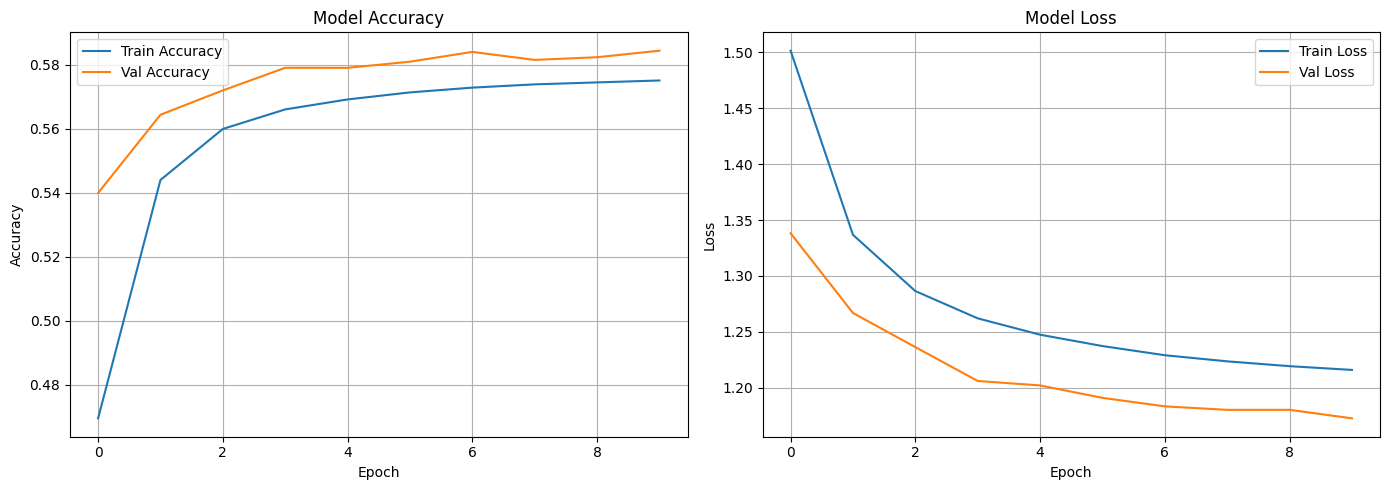

In [33]:
# =========================
# Plot Training History
# =========================

def plot_history(history):
    """Plot training and validation accuracy/loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
# =========================
# Evaluate Model
# =========================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Final evaluation
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

# Predictions
y_pred = model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_classes, target_names=[f'Col {i}' for i in range(7)]))

Training Accuracy: 0.5916
Validation Accuracy: 0.5843
Training Loss: 1.1521
Validation Loss: 1.1726

Classification Report:
              precision    recall  f1-score   support

       Col 0       0.58      0.49      0.53     16941
       Col 1       0.61      0.48      0.54     18816
       Col 2       0.56      0.58      0.57     22052
       Col 3       0.61      0.76      0.68     32541
       Col 4       0.58      0.57      0.58     22052
       Col 5       0.56      0.55      0.55     18816
       Col 6       0.56      0.51      0.53     16941

    accuracy                           0.58    148159
   macro avg       0.58      0.56      0.57    148159
weighted avg       0.58      0.58      0.58    148159



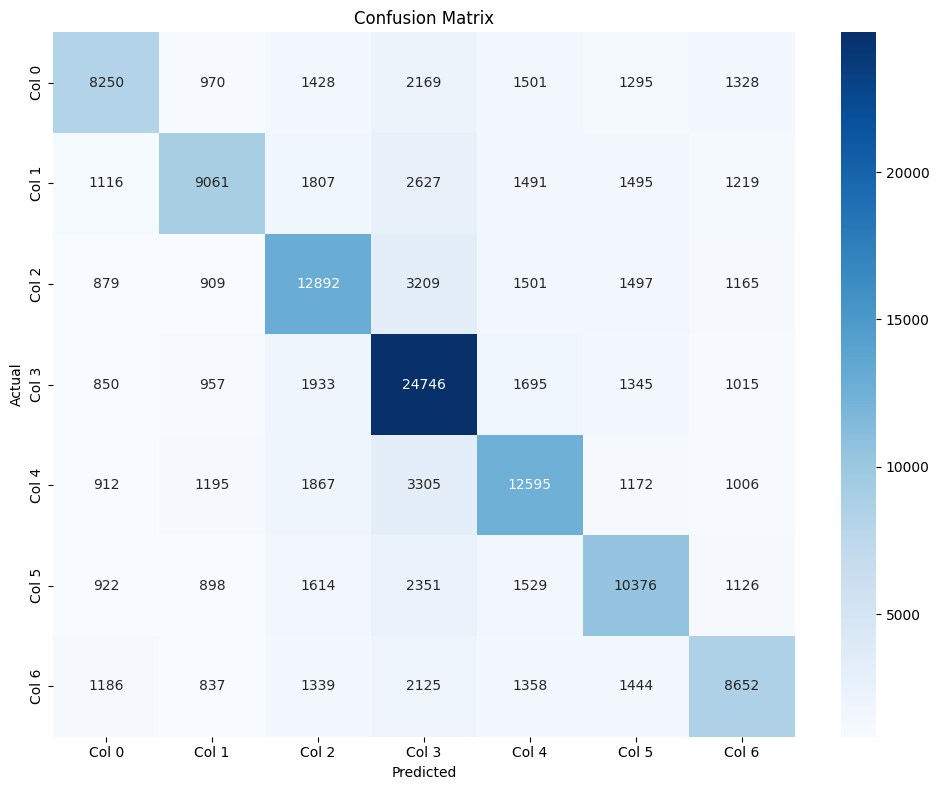

In [35]:
# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Col {i}' for i in range(7)],
            yticklabels=[f'Col {i}' for i in range(7)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# =============================================================================
# Hyperparameter Tuning - Experiment with Different Architectures
# =============================================================================
# Try multiple CNN configurations to find the best performing model.

In [60]:
# =========================
# Experiment Runner
# =========================

def run_experiment(config, X_train, y_train, X_val, y_val, epochs=50, verbose=0):
    """
    Run a single experiment with given configuration.
    Returns the model and training history.
    """
    # Clear previous model from memory
    keras.backend.clear_session()

    # Build model with config
    model = build_cnn(**config)

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3)),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=config.get('batch_size', 64),
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

    return {
        'config': config,
        'model': model,
        'history': history,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'train_loss': train_loss
    }

In [61]:
# =========================
# Define Experiment Configurations
# =========================

# Different architectures to try
experiments = [
    # Experiment 1: Shallow network
    {
        'name': 'Shallow (2 conv)',
        'conv_filters': [64, 128],
        'kernel_sizes': [4, 3],
        'dense_units': [128],
        'dropout_rate': 0.3,
        'l2_reg': 1e-4,
        'use_batch_norm': True,
    },
    # Experiment 2: Deep network
    {
        'name': 'Deep (4 conv)',
        'conv_filters': [32, 64, 128, 128],
        'kernel_sizes': [3, 3, 3, 3],
        'dense_units': [256, 128],
        'dropout_rate': 0.4,
        'l2_reg': 1e-4,
        'use_batch_norm': True,
    },
    # Experiment 3: Large filters (capture 4-in-a-row patterns)
    {
        'name': 'Large Filters (4x4)',
        'conv_filters': [64, 128, 128],
        'kernel_sizes': [4, 4, 3],
        'dense_units': [256, 128],
        'dropout_rate': 0.3,
        'l2_reg': 1e-4,
        'use_batch_norm': True,
    },
    # Experiment 4: More filters
    {
        'name': 'Wide (more filters)',
        'conv_filters': [128, 256, 256],
        'kernel_sizes': [3, 3, 3],
        'dense_units': [512, 256],
        'dropout_rate': 0.4,
        'l2_reg': 1e-4,
        'use_batch_norm': True,
    },
    # Experiment 5: Heavy regularization
    {
        'name': 'Heavy Regularization',
        'conv_filters': [64, 128, 128],
        'kernel_sizes': [4, 3, 3],
        'dense_units': [256, 128],
        'dropout_rate': 0.5,
        'l2_reg': 1e-3,
        'use_batch_norm': True,
    },
    # Experiment 6: No batch norm
    {
        'name': 'No BatchNorm',
        'conv_filters': [64, 128, 128],
        'kernel_sizes': [4, 3, 3],
        'dense_units': [256, 128],
        'dropout_rate': 0.3,
        'l2_reg': 1e-4,
        'use_batch_norm': False,
    },
    # Experiment 7: Small batch size
    {
        'name': 'Small Batch (32)',
        'conv_filters': [64, 128, 128],
        'kernel_sizes': [4, 3, 3],
        'dense_units': [256, 128],
        'dropout_rate': 0.6,
        'l2_reg': 1e-4,
        'use_batch_norm': True,
    },
]

print(f"Defined {len(experiments)} experiments to run")

Defined 7 experiments to run


In [62]:
# =========================
# Run All Experiments
# =========================

results = []

for i, exp in enumerate(experiments):
    name = exp.pop('name')
    print(f"\n{'='*60}")
    print(f"Experiment {i+1}/{len(experiments)}: {name}")
    print(f"{'='*60}")

    result = run_experiment(exp, X_train, y_train, X_val, y_val, epochs=50, verbose=0)
    result['name'] = name
    results.append(result)

    print(f"Train Acc: {result['train_acc']:.4f} | Val Acc: {result['val_acc']:.4f}")
    print(f"Train Loss: {result['train_loss']:.4f} | Val Loss: {result['val_loss']:.4f}")

print("\n" + "="*60)
print("All experiments completed!")
print("="*60)


Experiment 1/7: Shallow (2 conv)


KeyboardInterrupt: 

In [ ]:
# =========================
# Compare Results
# =========================

import pandas as pd

# Create comparison dataframe
comparison_data = []
for r in results:
    comparison_data.append({
        'Experiment': r['name'],
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}",
        'Train Loss': f"{r['train_loss']:.4f}",
        'Val Loss': f"{r['val_loss']:.4f}",
        'Epochs': len(r['history'].history['loss'])
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nExperiment Results Summary:")
print("="*80)
print(comparison_df.to_string(index=False))

# Find best model
best_idx = np.argmax([r['val_acc'] for r in results])
print(f"\nBest Model: {results[best_idx]['name']} with Val Accuracy: {results[best_idx]['val_acc']:.4f}")

In [ ]:
# =========================
# Visualize Experiment Comparison
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names = [r['name'] for r in results]
val_accs = [r['val_acc'] for r in results]
train_accs = [r['train_acc'] for r in results]

x = np.arange(len(names))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, train_accs, width, label='Train Acc', color='steelblue')
axes[0].bar(x + width/2, val_accs, width, label='Val Acc', color='coral')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Training curves for all experiments
for r in results:
    axes[1].plot(r['history'].history['val_accuracy'], label=r['name'], alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy During Training')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# Save Best Model and Create Prediction Function
# =============================================================================

In [ ]:
# =========================
# Save Best Model
# =========================

# Get the best model from experiments
best_result = results[best_idx]
best_model = best_result['model']

print(f"Best model: {best_result['name']}")
print(f"Validation Accuracy: {best_result['val_acc']:.4f}")

# Save in multiple formats for deployment to the Results folder
best_model.save('./connect4_cnn_best.keras')  # Keras native format
best_model.save('./connect4_cnn_best.h5')     # H5 format for compatibility

# best_model.save('.Results/connect4_cnn_best.keras')  # Keras native format
# best_model.save('.Results/connect4_cnn_best.h5')     # H5 format for compatibility

print("\nModel saved as:")
print("  - connect4_cnn_best.keras")
print("  - connect4_cnn_best.h5")

In [36]:
# Import the best model
# best_model = keras.models.load_model('.Results/connect4_cnn_best.keras')
best_model = keras.models.load_model('./best_cnn_model.keras')

In [37]:
# =========================
# CNN Prediction Function for Gameplay
# =========================

def cnn_predict_move(model, board, color):
    """
    Predict the best move for the given board state and player color.

    Args:
        model: Trained CNN model
        board: 6x7 numpy array with +1 (plus), -1 (minus), 0 (empty)
        color: 'plus' or 'minus' - which player is making the move

    Returns:
        Best column (0-6) to drop a checker
    """
    # Convert board to 2D representation (6,7,2)
    board_2d = board_to_2D(board)

    # If minus player, swap perspective so NN sees it as plus-to-move
    if color == 'minus':
        board_2d = board_2d[..., ::-1]

    # Add batch dimension and convert to float
    board_input = board_2d[np.newaxis, ...].astype(np.float32)

    # Get predictions
    predictions = model.predict(board_input, verbose=0)[0]

    # Find legal moves
    legal = find_legal(board)

    # Mask illegal moves with -inf
    masked_preds = np.full(7, -np.inf)
    for col in legal:
        masked_preds[col] = predictions[col]

    # Return the legal move with highest prediction
    return np.argmax(masked_preds)

# Test the prediction function
test_board = np.zeros((6, 7))
test_board = update_board(test_board, 'plus', 3)
test_board = update_board(test_board, 'minus', 3)

print("Test board:")
print(test_board)
print(f"\nCNN suggests column: {cnn_predict_move(best_model, test_board, 'plus')}")

Test board:
[[ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]]

CNN suggests column: 2


In [38]:
# =========================
# Play Against CNN Bot
# =========================

def play_against_cnn(model, human_color='plus'):
    """
    Play a game of Connect4 against the CNN bot.

    Args:
        model: Trained CNN model
        human_color: 'plus' or 'minus' - which color the human plays
    """
    board = np.zeros((6, 7))
    winner = 'nobody'
    current_player = 'plus'  # plus always goes first

    bot_color = 'minus' if human_color == 'plus' else 'plus'

    display_board(board)

    while winner == 'nobody':
        legal = find_legal(board)
        if len(legal) == 0:
            print("It's a tie!")
            return 'tie'

        if current_player == human_color:
            # Human's turn
            move = input(f'Your turn ({human_color}). Pick a column (0-6): ')
            try:
                move = int(move)
                if move not in legal:
                    print(f"Illegal move! Legal moves are: {legal}")
                    continue
            except ValueError:
                print("Please enter a number 0-6")
                continue
        else:
            # CNN bot's turn
            move = cnn_predict_move(model, board, current_player)
            print(f"CNN bot plays column: {move}")

        board = update_board(board, current_player, move)
        display_board(board)
        winner = check_for_win(board, move)

        # Switch player
        current_player = 'minus' if current_player == 'plus' else 'plus'

    if 'plus' in winner:
        winning_color = 'plus'
    else:
        winning_color = 'minus'

    if winning_color == human_color:
        print("Congratulations! You won!")
    else:
        print("CNN bot wins!")

    return winner

# Uncomment to play:
# play_against_cnn(best_model, human_color='plus')

In [39]:
# =========================
# Test CNN vs MCTS
# =========================

def cnn_vs_mcts(model, n_games=20, mcts_steps=500):
    """
    Play games between CNN and MCTS to evaluate performance.

    Args:
        model: Trained CNN model
        n_games: Number of games to play
        mcts_steps: MCTS strength (higher = stronger)

    Returns:
        Dictionary with results
    """
    results = {'cnn_wins': 0, 'mcts_wins': 0, 'ties': 0}

    for game in range(n_games):
        board = np.zeros((6, 7))
        winner = 'nobody'

        # Alternate who goes first
        cnn_color = 'plus' if game % 2 == 0 else 'minus'
        mcts_color = 'minus' if cnn_color == 'plus' else 'plus'
        current = 'plus'

        while winner == 'nobody':
            legal = find_legal(board)
            if len(legal) == 0:
                winner = 'tie'
                break

            if current == cnn_color:
                move = cnn_predict_move(model, board, current)
            else:
                move = mcts(board, current, mcts_steps)

            board = update_board(board, current, move)
            winner = check_for_win(board, move)
            current = 'minus' if current == 'plus' else 'plus'

        if winner == 'tie':
            results['ties'] += 1
        elif (cnn_color == 'plus' and 'plus' in winner) or (cnn_color == 'minus' and 'minus' in winner):
            results['cnn_wins'] += 1
        else:
            results['mcts_wins'] += 1

        if (game + 1) % 5 == 0:
            print(f"Games completed: {game+1}/{n_games}")

    return results

print("Testing CNN against MCTS (this may take a few minutes)...")
print("="*50)
mcts_steps = 1000
eval_results = cnn_vs_mcts(best_model, n_games=20, mcts_steps=mcts_steps)

print(f"\nResults (20 games vs MCTS-{mcts_steps}):")
print(f"  CNN Wins: {eval_results['cnn_wins']}")
print(f"  MCTS Wins: {eval_results['mcts_wins']}")
print(f"  Ties: {eval_results['ties']}")
print(f"  CNN Win Rate: {eval_results['cnn_wins']/20*100:.1f}%")

Testing CNN against MCTS (this may take a few minutes)...
Games completed: 5/20
Games completed: 10/20
Games completed: 15/20
Games completed: 20/20

Results (20 games vs MCTS-1000):
  CNN Wins: 10
  MCTS Wins: 9
  Ties: 1
  CNN Win Rate: 50.0%


In [40]:
print("Testing CNN against MCTS (this may take a few minutes)...")
print("="*50)
mcts_steps = 3000
eval_results = cnn_vs_mcts(best_model, n_games=20, mcts_steps=mcts_steps)

print(f"\nResults (20 games vs MCTS-{mcts_steps}):")
print(f"  CNN Wins: {eval_results['cnn_wins']}")
print(f"  MCTS Wins: {eval_results['mcts_wins']}")
print(f"  Ties: {eval_results['ties']}")
print(f"  CNN Win Rate: {eval_results['cnn_wins']/20*100:.1f}%")

Testing CNN against MCTS (this may take a few minutes)...
Games completed: 5/20
Games completed: 10/20
Games completed: 15/20
Games completed: 20/20

Results (20 games vs MCTS-3000):
  CNN Wins: 8
  MCTS Wins: 11
  Ties: 1
  CNN Win Rate: 40.0%


In [41]:
print("Testing CNN against MCTS (this may take a few minutes)...")
print("="*50)
mcts_steps = 500
eval_results = cnn_vs_mcts(best_model, n_games=20, mcts_steps=mcts_steps)

print(f"\nResults (20 games vs MCTS-{mcts_steps}):")
print(f"  CNN Wins: {eval_results['cnn_wins']}")
print(f"  MCTS Wins: {eval_results['mcts_wins']}")
print(f"  Ties: {eval_results['ties']}")
print(f"  CNN Win Rate: {eval_results['cnn_wins']/20*100:.1f}%")

Testing CNN against MCTS (this may take a few minutes)...
Games completed: 5/20
Games completed: 10/20
Games completed: 15/20
Games completed: 20/20

Results (20 games vs MCTS-500):
  CNN Wins: 14
  MCTS Wins: 6
  Ties: 0
  CNN Win Rate: 70.0%


In [42]:
print("Testing CNN against MCTS (this may take a few minutes)...")
print("="*50)
mcts_steps = 100
eval_results = cnn_vs_mcts(best_model, n_games=20, mcts_steps=mcts_steps)

print(f"\nResults (20 games vs MCTS-{mcts_steps}):")
print(f"  CNN Wins: {eval_results['cnn_wins']}")
print(f"  MCTS Wins: {eval_results['mcts_wins']}")
print(f"  Ties: {eval_results['ties']}")
print(f"  CNN Win Rate: {eval_results['cnn_wins']/20*100:.1f}%")

Testing CNN against MCTS (this may take a few minutes)...
Games completed: 5/20
Games completed: 10/20
Games completed: 15/20
Games completed: 20/20

Results (20 games vs MCTS-100):
  CNN Wins: 19
  MCTS Wins: 1
  Ties: 0
  CNN Win Rate: 95.0%


In [ ]:
# =========================
# Transformer Building Blocks
# =========================

class PositionalIndex(tf.keras.layers.Layer):
    """Generate positional indices for each patch in the sequence."""
    def call(self, x):
        bs = tf.shape(x)[0]  # batch size
        num_patches = tf.shape(x)[1]  # number of patches/tokens
        indices = tf.range(num_patches)
        indices = tf.expand_dims(indices, 0)
        return tf.tile(indices, [bs, 1])


class ClassTokenIndex(tf.keras.layers.Layer):
    """Generate index for the class token (always 0)."""
    def call(self, x):
        bs = tf.shape(x)[0]
        indices = tf.range(1)  # just index 0
        indices = tf.expand_dims(indices, 0)
        return tf.tile(indices, [bs, 1])


print("Transformer building blocks defined.")

In [ ]:
# =========================
# Vision Transformer for Connect4
# =========================

def build_connect4_transformer(
    num_patches,
    patch_dim,
    hidden_dim=64,
    num_layers=4,
    num_heads=4,
    key_dim=None,
    value_dim=None,
    mlp_dim=128,
    dropout_rate=0.1,
    num_classes=7
):
    """
    Build a Vision Transformer for Connect4 move prediction.

    Args:
        num_patches: Number of patches the board is divided into
        patch_dim: Dimension of each patch (flattened)
        hidden_dim: Hidden dimension for transformer
        num_layers: Number of transformer encoder layers
        num_heads: Number of attention heads
        key_dim: Dimension for keys/queries (default: hidden_dim // num_heads)
        value_dim: Dimension for values (default: key_dim * 2)
        mlp_dim: Dimension of feedforward network
        dropout_rate: Dropout rate for regularization
        num_classes: Number of output classes (7 for Connect4 columns)

    Returns:
        Compiled Keras model
    """
    if key_dim is None:
        key_dim = hidden_dim // num_heads
    if value_dim is None:
        value_dim = key_dim * 2

    # Input: (batch, num_patches, patch_dim)
    inp = tf.keras.layers.Input(shape=(num_patches, patch_dim))

    # Linear projection to hidden dimension
    mid = tf.keras.layers.Dense(hidden_dim, use_bias=False, name='patch_embed')(inp)

    # Add positional embeddings
    pos_indices = PositionalIndex()(inp)
    pos_embed = tf.keras.layers.Embedding(
        input_dim=num_patches,
        output_dim=hidden_dim,
        name='pos_embed'
    )(pos_indices)
    mid = tf.keras.layers.Add(name='add_pos_embed')([mid, pos_embed])

    # Add class token
    token_idx = ClassTokenIndex()(mid)
    class_token = tf.keras.layers.Embedding(
        input_dim=1,
        output_dim=hidden_dim,
        name='class_token'
    )(token_idx)
    mid = tf.keras.layers.Concatenate(axis=1, name='concat_cls')([class_token, mid])

    # Transformer encoder layers
    for layer_idx in range(num_layers):
        # Layer normalization + Multi-Head Self-Attention
        ln1 = tf.keras.layers.LayerNormalization(name=f'ln1_{layer_idx}')(mid)
        mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,
            value_dim=value_dim,
            dropout=dropout_rate,
            name=f'mha_{layer_idx}'
        )(ln1, ln1, ln1)
        mid = tf.keras.layers.Add(name=f'add1_{layer_idx}')([mid, mha])

        # Layer normalization + MLP
        ln2 = tf.keras.layers.LayerNormalization(name=f'ln2_{layer_idx}')(mid)
        mlp = tf.keras.layers.Dense(mlp_dim, activation='gelu', name=f'mlp1_{layer_idx}')(ln2)
        mlp = tf.keras.layers.Dropout(dropout_rate, name=f'drop1_{layer_idx}')(mlp)
        mlp = tf.keras.layers.Dense(hidden_dim, name=f'mlp2_{layer_idx}')(mlp)
        mlp = tf.keras.layers.Dropout(dropout_rate, name=f'drop2_{layer_idx}')(mlp)
        mid = tf.keras.layers.Add(name=f'add2_{layer_idx}')([mid, mlp])

    # Extract class token (first token)
    cls_output = mid[:, 0, :]

    # Final layer normalization and classification
    ln_final = tf.keras.layers.LayerNormalization(name='ln_final')(cls_output)
    output = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(ln_final)

    model = tf.keras.models.Model(inp, output)
    return model

print("build_connect4_transformer() defined.")

In [ ]:
# =========================
# Patch Extraction for Transformer
# =========================

def extract_patches_no_overlap(boards, patch_rows=2, patch_cols=2):
    """
    Extract non-overlapping patches from boards.

    Args:
        boards: (N, 6, 7, 2) array of board states
        patch_rows: Height of each patch
        patch_cols: Width of each patch

    Returns:
        (N, num_patches, patch_dim) array
    """
    N, H, W, C = boards.shape  # (N, 6, 7, 2)

    # Calculate number of patches
    n_rows = H // patch_rows
    n_cols = W // patch_cols
    num_patches = n_rows * n_cols
    patch_dim = patch_rows * patch_cols * C

    patches = np.zeros((N, num_patches, patch_dim), dtype=np.float32)

    idx = 0
    for r in range(n_rows):
        for c in range(n_cols):
            r_start = r * patch_rows
            r_end = r_start + patch_rows
            c_start = c * patch_cols
            c_end = c_start + patch_cols
            patch = boards[:, r_start:r_end, c_start:c_end, :]
            patches[:, idx, :] = patch.reshape(N, -1)
            idx += 1

    return patches, num_patches, patch_dim


def extract_patches_overlap(boards, patch_rows=4, patch_cols=4, stride_rows=1, stride_cols=1):
    """
    Extract overlapping patches from boards.
    Overlapping patches can better capture connect-4 patterns (4 in a row).

    Args:
        boards: (N, 6, 7, 2) array of board states
        patch_rows: Height of each patch (4 is good for connect-4 patterns)
        patch_cols: Width of each patch
        stride_rows: Vertical stride between patches
        stride_cols: Horizontal stride between patches

    Returns:
        (N, num_patches, patch_dim) array
    """
    N, H, W, C = boards.shape  # (N, 6, 7, 2)

    # Calculate number of patches
    n_rows = (H - patch_rows) // stride_rows + 1
    n_cols = (W - patch_cols) // stride_cols + 1
    num_patches = n_rows * n_cols
    patch_dim = patch_rows * patch_cols * C

    patches = np.zeros((N, num_patches, patch_dim), dtype=np.float32)

    idx = 0
    for r in range(n_rows):
        for c in range(n_cols):
            r_start = r * stride_rows
            r_end = r_start + patch_rows
            c_start = c * stride_cols
            c_end = c_start + patch_cols
            patch = boards[:, r_start:r_end, c_start:c_end, :]
            patches[:, idx, :] = patch.reshape(N, -1)
            idx += 1

    return patches, num_patches, patch_dim


def extract_patches_cells(boards):
    """
    Treat each cell as a separate patch (1x1).
    This gives 42 patches, each with dimension 2.

    Args:
        boards: (N, 6, 7, 2) array of board states

    Returns:
        (N, 42, 2) array
    """
    N = boards.shape[0]
    # Reshape to (N, 42, 2)
    patches = boards.reshape(N, -1, 2).astype(np.float32)
    num_patches = 42
    patch_dim = 2
    return patches, num_patches, patch_dim


print("Patch extraction functions defined.")
print("  - extract_patches_no_overlap(): Non-overlapping patches")
print("  - extract_patches_overlap(): Overlapping patches (recommended for Connect4)")
print("  - extract_patches_cells(): Each cell as a patch (42 patches)")

In [ ]:
# =========================
# Prepare Data for Transformer
# =========================
# Use the already-loaded and normalized data (X_norm, y, X_train, X_val, y_train, y_val)

# Method 1: Overlapping 4x4 patches (captures connect-4 patterns)
# With stride 1, we get (6-4+1) * (7-4+1) = 3 * 4 = 12 patches
X_train_patches_overlap, num_patches_overlap, patch_dim_overlap = extract_patches_overlap(
    X_train, patch_rows=4, patch_cols=4, stride_rows=1, stride_cols=1
)
X_val_patches_overlap, _, _ = extract_patches_overlap(
    X_val, patch_rows=4, patch_cols=4, stride_rows=1, stride_cols=1
)

print(f"Overlapping 4x4 patches (stride=1):")
print(f"  Train shape: {X_train_patches_overlap.shape}")
print(f"  Val shape: {X_val_patches_overlap.shape}")
print(f"  Num patches: {num_patches_overlap}, Patch dim: {patch_dim_overlap}")

# Method 2: Each cell as a patch (42 patches of dim 2)
X_train_patches_cells, num_patches_cells, patch_dim_cells = extract_patches_cells(X_train)
X_val_patches_cells, _, _ = extract_patches_cells(X_val)

print(f"\nCell-based patches (1x1):")
print(f"  Train shape: {X_train_patches_cells.shape}")
print(f"  Val shape: {X_val_patches_cells.shape}")
print(f"  Num patches: {num_patches_cells}, Patch dim: {patch_dim_cells}")

In [ ]:
# =========================
# Build Base Transformer Model
# =========================

# Using overlapping patches (recommended for Connect4)
transformer_model = build_connect4_transformer(
    num_patches=num_patches_overlap,
    patch_dim=patch_dim_overlap,
    hidden_dim=64,
    num_layers=4,
    num_heads=4,
    key_dim=16,       # hidden_dim // num_heads
    value_dim=32,     # key_dim * 2
    mlp_dim=128,
    dropout_rate=0.1,
    num_classes=7
)

# Compile with Adam optimizer
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()

In [ ]:
# =========================
# Train Transformer Model
# =========================

# Callbacks
transformer_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_transformer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train
BATCH_SIZE = 64
EPOCHS = 100

transformer_history = transformer_model.fit(
    X_train_patches_overlap, y_train,
    validation_data=(X_val_patches_overlap, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=transformer_callbacks,
    verbose=1
)

In [ ]:
# =========================
# Plot Transformer Training History
# =========================

plot_history(transformer_history)

In [ ]:
# =========================
# Evaluate Transformer Model
# =========================

# Final evaluation
trans_train_loss, trans_train_acc = transformer_model.evaluate(X_train_patches_overlap, y_train, verbose=0)
trans_val_loss, trans_val_acc = transformer_model.evaluate(X_val_patches_overlap, y_val, verbose=0)

print(f"Transformer Training Accuracy: {trans_train_acc:.4f}")
print(f"Transformer Validation Accuracy: {trans_val_acc:.4f}")
print(f"Transformer Training Loss: {trans_train_loss:.4f}")
print(f"Transformer Validation Loss: {trans_val_loss:.4f}")

# Predictions and classification report
y_pred_trans = transformer_model.predict(X_val_patches_overlap, verbose=0)
y_pred_trans_classes = np.argmax(y_pred_trans, axis=1)

print("\nTransformer Classification Report:")
print(classification_report(y_val, y_pred_trans_classes, target_names=[f'Col {i}' for i in range(7)]))

# =============================================================================
# Transformer Hyperparameter Tuning
# =============================================================================
# Experiment with different architectures to find the best transformer for Connect4.

In [ ]:
# =========================
# Transformer Experiment Runner
# =========================

def run_transformer_experiment(config, X_train, y_train, X_val, y_val, epochs=50, verbose=0):
    """
    Run a single transformer experiment with given configuration.
    """
    keras.backend.clear_session()

    # Build model
    model = build_connect4_transformer(
        num_patches=config['num_patches'],
        patch_dim=config['patch_dim'],
        hidden_dim=config.get('hidden_dim', 64),
        num_layers=config.get('num_layers', 4),
        num_heads=config.get('num_heads', 4),
        key_dim=config.get('key_dim', None),
        value_dim=config.get('value_dim', None),
        mlp_dim=config.get('mlp_dim', 128),
        dropout_rate=config.get('dropout_rate', 0.1),
        num_classes=7
    )

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3)),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=config.get('batch_size', 64),
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

    return {
        'config': config,
        'model': model,
        'history': history,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'train_loss': train_loss
    }

print("run_transformer_experiment() defined.")

In [ ]:
# =========================
# Transformer Experiment Configurations
# =========================

transformer_experiments = [
    # Experiment 1: Small model with overlapping patches
    {
        'name': 'Small (4x4 overlap)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 32,
        'num_layers': 2,
        'num_heads': 2,
        'mlp_dim': 64,
        'dropout_rate': 0.1,
        'batch_size': 64
    },
    # Experiment 2: Medium model
    {
        'name': 'Medium (4x4 overlap)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 64,
        'num_layers': 4,
        'num_heads': 4,
        'mlp_dim': 128,
        'dropout_rate': 0.1,
        'batch_size': 64
    },
    # Experiment 3: Large model
    {
        'name': 'Large (4x4 overlap)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 128,
        'num_layers': 6,
        'num_heads': 8,
        'mlp_dim': 256,
        'dropout_rate': 0.2,
        'batch_size': 64
    },
    # Experiment 4: Cell-based patches (42 patches of dim 2)
    {
        'name': 'Cell-based (42 patches)',
        'num_patches': num_patches_cells,
        'patch_dim': patch_dim_cells,
        'hidden_dim': 64,
        'num_layers': 4,
        'num_heads': 4,
        'mlp_dim': 128,
        'dropout_rate': 0.1,
        'batch_size': 64
    },
    # Experiment 5: More attention heads
    {
        'name': 'More Heads (8)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 64,
        'num_layers': 4,
        'num_heads': 8,
        'key_dim': 8,
        'value_dim': 16,
        'mlp_dim': 128,
        'dropout_rate': 0.1,
        'batch_size': 64
    },
    # Experiment 6: Deeper with smaller hidden dim
    {
        'name': 'Deep Narrow (8 layers)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 48,
        'num_layers': 8,
        'num_heads': 4,
        'mlp_dim': 96,
        'dropout_rate': 0.15,
        'batch_size': 64
    },
    # Experiment 7: Higher dropout
    {
        'name': 'High Dropout (0.3)',
        'num_patches': num_patches_overlap,
        'patch_dim': patch_dim_overlap,
        'hidden_dim': 64,
        'num_layers': 4,
        'num_heads': 4,
        'mlp_dim': 128,
        'dropout_rate': 0.3,
        'batch_size': 64
    },
]

print(f"Defined {len(transformer_experiments)} transformer experiments")

In [ ]:
# =========================
# Run Transformer Experiments
# =========================

transformer_results = []

for i, exp in enumerate(transformer_experiments):
    name = exp.pop('name')

    # Select appropriate patch data
    if exp['num_patches'] == num_patches_cells:
        X_tr, X_vl = X_train_patches_cells, X_val_patches_cells
    else:
        X_tr, X_vl = X_train_patches_overlap, X_val_patches_overlap

    print(f"\n{'='*60}")
    print(f"Transformer Experiment {i+1}/{len(transformer_experiments)}: {name}")
    print(f"{'='*60}")

    result = run_transformer_experiment(exp, X_tr, y_train, X_vl, y_val, epochs=50, verbose=0)
    result['name'] = name
    transformer_results.append(result)

    print(f"Train Acc: {result['train_acc']:.4f} | Val Acc: {result['val_acc']:.4f}")
    print(f"Train Loss: {result['train_loss']:.4f} | Val Loss: {result['val_loss']:.4f}")

print("\n" + "="*60)
print("All transformer experiments completed!")
print("="*60)

In [ ]:
# =========================
# Compare Transformer Results
# =========================

# Create comparison dataframe
trans_comparison_data = []
for r in transformer_results:
    trans_comparison_data.append({
        'Experiment': r['name'],
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}",
        'Train Loss': f"{r['train_loss']:.4f}",
        'Val Loss': f"{r['val_loss']:.4f}",
        'Epochs': len(r['history'].history['loss'])
    })

trans_comparison_df = pd.DataFrame(trans_comparison_data)
print("\nTransformer Experiment Results Summary:")
print("="*80)
print(trans_comparison_df.to_string(index=False))

# Find best transformer model
best_trans_idx = np.argmax([r['val_acc'] for r in transformer_results])
print(f"\nBest Transformer: {transformer_results[best_trans_idx]['name']}")
print(f"Validation Accuracy: {transformer_results[best_trans_idx]['val_acc']:.4f}")

In [ ]:
# =========================
# Visualize Transformer Experiment Comparison
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names = [r['name'] for r in transformer_results]
val_accs = [r['val_acc'] for r in transformer_results]
train_accs = [r['train_acc'] for r in transformer_results]

x = np.arange(len(names))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, train_accs, width, label='Train Acc', color='steelblue')
axes[0].bar(x + width/2, val_accs, width, label='Val Acc', color='coral')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Transformer: Training vs Validation Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Training curves for all experiments
for r in transformer_results:
    axes[1].plot(r['history'].history['val_accuracy'], label=r['name'], alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Transformer Validation Accuracy During Training')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# Save Best Transformer and Create Prediction Function
# =============================================================================

In [ ]:
# =========================
# Save Best Transformer Model
# =========================

best_trans_result = transformer_results[best_trans_idx]
best_trans_model = best_trans_result['model']

print(f"Best transformer: {best_trans_result['name']}")

# # Save in multiple formats
# best_trans_model.save('./Results/connect4_transformer_best.keras')
# best_trans_model.save('./Results/connect4_transformer_best.h5')

best_trans_model.save('./connect4_transformer_best.keras')
best_trans_model.save('./connect4_transformer_best.h5')

print("\nTransformer model saved as:")
print("  - connect4_transformer_best.keras")
print("  - connect4_transformer_best.h5")

In [ ]:
# =========================
# Transformer Prediction Function for Gameplay
# =========================

def transformer_predict_move(model, board, color, patch_type='overlap'):
    """
    Predict the best move using the transformer model.

    Args:
        model: Trained transformer model
        board: 6x7 numpy array with +1 (plus), -1 (minus), 0 (empty)
        color: 'plus' or 'minus' - which player is making the move
        patch_type: 'overlap' for 4x4 overlapping patches, 'cells' for cell-based

    Returns:
        Best column (0-6) to drop a checker
    """
    # Convert board to 2D representation (6,7,2)
    board_2d = board_to_2D(board)

    # If minus player, swap perspective
    if color == 'minus':
        board_2d = board_2d[..., ::-1]

    # Add batch dimension
    board_batch = board_2d[np.newaxis, ...].astype(np.float32)

    # Extract patches
    if patch_type == 'cells':
        patches, _, _ = extract_patches_cells(board_batch)
    else:
        patches, _, _ = extract_patches_overlap(board_batch, patch_rows=4, patch_cols=4)

    # Get predictions
    predictions = model.predict(patches, verbose=0)[0]

    # Find legal moves
    legal = find_legal(board)

    # Mask illegal moves
    masked_preds = np.full(7, -np.inf)
    for col in legal:
        masked_preds[col] = predictions[col]

    return np.argmax(masked_preds)

# Test the prediction function
test_board = np.zeros((6, 7))
test_board = update_board(test_board, 'plus', 3)
test_board = update_board(test_board, 'minus', 3)

print("Test board:")
print(test_board)
print(f"\nTransformer suggests column: {transformer_predict_move(best_trans_model, test_board, 'plus')}")

# =============================================================================
# Compare CNN vs Transformer
# =============================================================================

In [ ]:
# =========================
# CNN vs Transformer Comparison
# =========================

print("="*60)
print("MODEL COMPARISON: CNN vs Transformer")
print("="*60)

# Get best results from each (assuming results exist from earlier cells)
try:
    best_cnn = results[best_idx]  # From CNN experiments
    print(f"\nBest CNN: {best_cnn['name']}")
    print(f"  Train Accuracy: {best_cnn['train_acc']:.4f}")
    print(f"  Val Accuracy: {best_cnn['val_acc']:.4f}")
except:
    print("\nCNN results not available - run CNN experiments first")

print(f"\nBest Transformer: {best_trans_result['name']}")
print(f"  Train Accuracy: {best_trans_result['train_acc']:.4f}")
print(f"  Val Accuracy: {best_trans_result['val_acc']:.4f}")

# Visual comparison
try:
    fig, ax = plt.subplots(figsize=(10, 6))

    models = ['CNN\n' + best_cnn['name'], 'Transformer\n' + best_trans_result['name']]
    train_accs = [best_cnn['train_acc'], best_trans_result['train_acc']]
    val_accs = [best_cnn['val_acc'], best_trans_result['val_acc']]

    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
    bars2 = ax.bar(x + width/2, val_accs, width, label='Val Accuracy', color='coral')

    ax.set_ylabel('Accuracy')
    ax.set_title('CNN vs Transformer: Best Model Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
except:
    print("\nCannot create comparison plot - run both CNN and Transformer experiments first")

In [ ]:
# =========================
# Test Transformer vs MCTS
# =========================

def transformer_vs_mcts(model, n_games=20, mcts_steps=500, patch_type='overlap'):
    """
    Play games between Transformer and MCTS to evaluate performance.
    """
    results = {'trans_wins': 0, 'mcts_wins': 0, 'ties': 0}

    for game in range(n_games):
        board = np.zeros((6, 7))
        winner = 'nobody'

        trans_color = 'plus' if game % 2 == 0 else 'minus'
        mcts_color = 'minus' if trans_color == 'plus' else 'plus'
        current = 'plus'

        while winner == 'nobody':
            legal = find_legal(board)
            if len(legal) == 0:
                winner = 'tie'
                break

            if current == trans_color:
                move = transformer_predict_move(model, board, current, patch_type)
            else:
                move = mcts(board, current, mcts_steps)

            board = update_board(board, current, move)
            winner = check_for_win(board, move)
            current = 'minus' if current == 'plus' else 'plus'

        if winner == 'tie':
            results['ties'] += 1
        elif (trans_color == 'plus' and 'plus' in winner) or (trans_color == 'minus' and 'minus' in winner):
            results['trans_wins'] += 1
        else:
            results['mcts_wins'] += 1

        if (game + 1) % 5 == 0:
            print(f"Games completed: {game+1}/{n_games}")

    return results

print("Testing Transformer against MCTS (this may take a few minutes)...")
print("="*50)
trans_eval_results = transformer_vs_mcts(best_trans_model, n_games=20, mcts_steps=3000)

print(f"\nResults (20 games vs MCTS-3000):")
print(f"  Transformer Wins: {trans_eval_results['trans_wins']}")
print(f"  MCTS Wins: {trans_eval_results['mcts_wins']}")
print(f"  Ties: {trans_eval_results['ties']}")
print(f"  Transformer Win Rate: {trans_eval_results['trans_wins']/20*100:.1f}%")

In [ ]:
# =========================
# Play Against Transformer Bot
# =========================

def play_against_transformer(model, human_color='plus', patch_type='overlap'):
    """
    Play a game of Connect4 against the Transformer bot.
    """
    board = np.zeros((6, 7))
    winner = 'nobody'
    current_player = 'plus'

    bot_color = 'minus' if human_color == 'plus' else 'plus'

    display_board(board)

    while winner == 'nobody':
        legal = find_legal(board)
        if len(legal) == 0:
            print("It's a tie!")
            return 'tie'

        if current_player == human_color:
            move = input(f'Your turn ({human_color}). Pick a column (0-6): ')
            try:
                move = int(move)
                if move not in legal:
                    print(f"Illegal move! Legal moves are: {legal}")
                    continue
            except ValueError:
                print("Please enter a number 0-6")
                continue
        else:
            move = transformer_predict_move(model, board, current_player, patch_type)
            print(f"Transformer bot plays column: {move}")

        board = update_board(board, current_player, move)
        display_board(board)
        winner = check_for_win(board, move)

        current_player = 'minus' if current_player == 'plus' else 'plus'

    if 'plus' in winner:
        winning_color = 'plus'
    else:
        winning_color = 'minus'

    if winning_color == human_color:
        print("Congratulations! You won!")
    else:
        print("Transformer bot wins!")

    return winner

# Uncomment to play:
# play_against_transformer(best_trans_model, human_color='plus')